CHARGEMENT ET COMPREHENSION BASIQUE DES DONNEES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv('../data/raw/Churn_Modelling.csv')

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Nombre de lignes et de colonnes
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de lignes : 10000
Nombre de colonnes : 14


In [3]:
# Types de données
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [4]:
#valeurs manquantes
missing_values = df.isnull().sum()
missing_values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
# Doublons
duplicate_rows = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {duplicate_rows}")

Nombre de lignes dupliquées : 0


In [6]:
# Exclure les colonnes inutiles
drop_columns = ['RowNumber', 'CustomerId', 'Surname', 'Gender']
df = df.drop(drop_columns, axis=1)
df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,502,France,42,8,159660.80,3,1,0,113931.57,1
3,699,France,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Statistiques descriptives
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


COMPRHENSION STRUCTURELLE DES DONNEES

In [8]:
binary_vars = ['HasCrCard', 'IsActiveMember', 'Exited']

# identifier les colonnes numériques
all_numerical_vars = df.select_dtypes(include=[np.number]).columns.tolist()

numerical_features = [
    col for col in all_numerical_vars
    if col not in binary_vars
]

# identifier les colonnes catégorielles
categorical_features = df.select_dtypes(include=[object, "string"]).columns.tolist()
categorical_features += binary_vars

print("Colonnes numériques :", numerical_features)
print("Colonnes catégorielles :", categorical_features)

Colonnes numériques : ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
Colonnes catégorielles : ['Geography', 'HasCrCard', 'IsActiveMember', 'Exited']


In [9]:
# identifier la variable cible
target_variable = 'Exited'
df[target_variable].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

ANALYSE UNIVARIEE

Pour lire un histogramme :
- L’axe horizontal montre les valeurs possibles (par exemple l’`Age` ou le `CreditScore`).
- L’axe vertical montre combien de clients se trouvent dans chaque intervalle.
- Une colonne haute signifie beaucoup de clients dans cette plage de valeurs.
- La moyenne et la médiane aident à voir si la distribution est centrée ou décalée.

--- CreditScore ---


count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

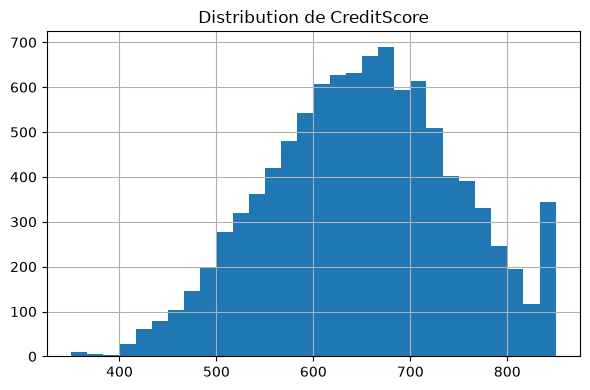

--- Age ---


count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

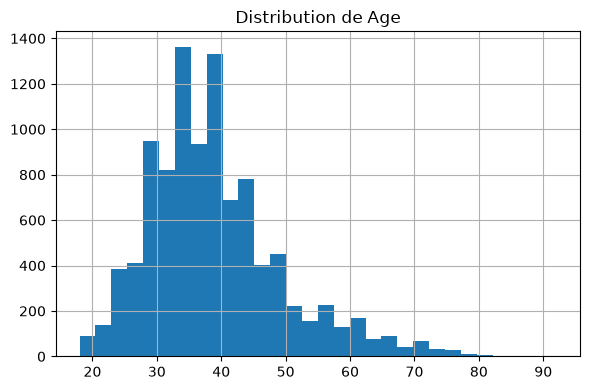

--- Tenure ---


count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64

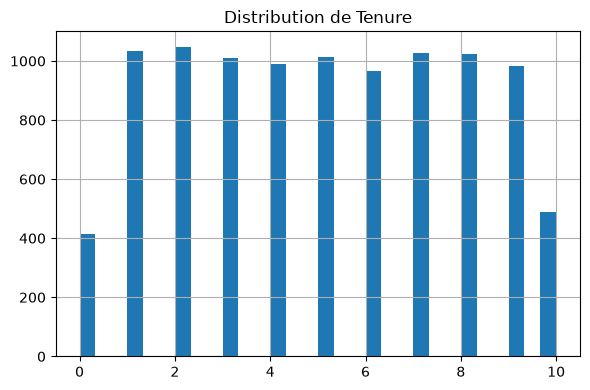

--- Balance ---


count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

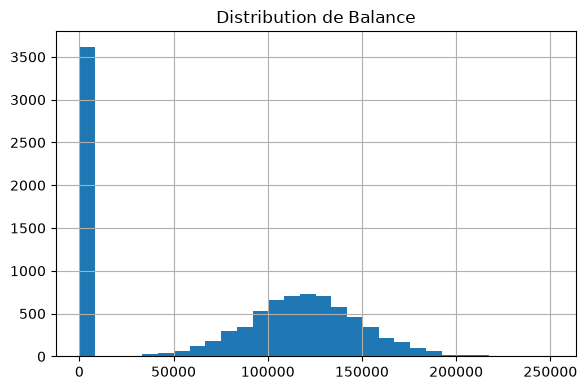

--- NumOfProducts ---


count    10000.000000
mean         1.530200
std          0.581654
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: NumOfProducts, dtype: float64

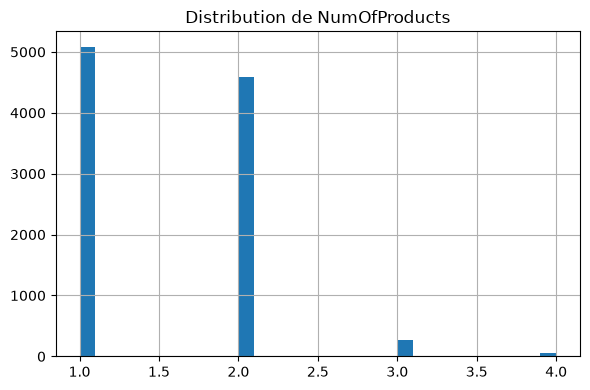

--- EstimatedSalary ---


count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

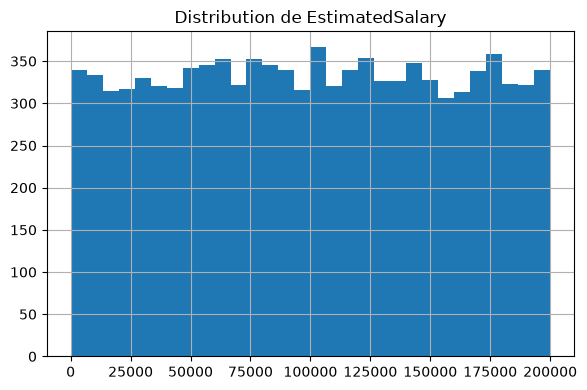

In [10]:
for col in numerical_features:
    print(f"--- {col} ---")
    display(df[col].describe())
#    print("Skewness:", df[col].skew())
    plt.figure(figsize=(6,4))
    df[col].hist(bins=30)
    plt.title(f"Distribution de {col}")
    plt.tight_layout()
    plt.show()

In [11]:
for col in categorical_features:
    print(f"--- {col} ---")
    display(df[col].value_counts(normalize=True) * 100)

--- Geography ---


Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

--- HasCrCard ---


HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64

--- IsActiveMember ---


IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64

--- Exited ---


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

---
###  Interprétation — Bloc 2 : Analyse Univariée

**Ce qu'on retient de l'exploration de chaque variable prise isolément :**

1. **Déséquilibre de la cible `Exited`**  
   Environ **80% des clients restent** et seulement **20% quittent** la banque.  
    *Impact* : Un modèle naïf qui prédirait toujours « le client reste » aurait déjà 80% de bonnes réponses sans rien apprendre.  
   → Il faudra évaluer nos modèles avec des métriques adaptées : **Recall**, **F1-score**, et non l'Accuracy seule.

2. **Asymétrie forte sur `Balance` (solde bancaire)**  
   Plus de **35% des clients ont un solde égal à 0**, créant un pic massif à gauche de l'histogramme. Les autres ont un solde distribué normalement autour de 120 000.  
   → Il y a deux profils distincts de clients à garder en tête pour la Phase 3.

3. **`Tenure` et `EstimatedSalary` sont uniformément répartis**  
   Pas d'anomalie ni de valeurs aberrantes sur ces deux variables. Elles sont stables et propres.

ANALYSE BIVARIEE


   ANALYSE DE LA VARIABLE : CreditScore

--- Statistiques de CreditScore selon le churn (Exited) ---


,mean,median
Exited,,
0,651.853196,653.0
1,645.351497,646.0


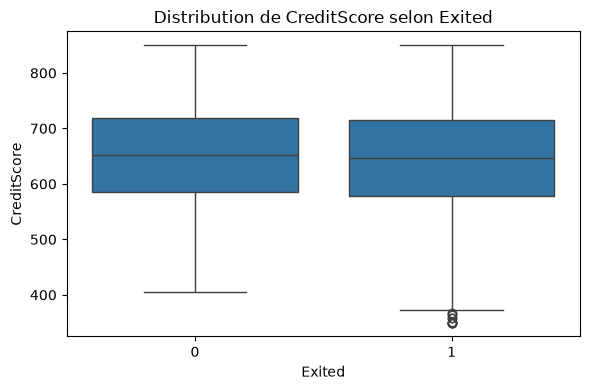


--- Taux de Churn selon les tranches de CreditScore ---


,Taux de Churn (%)
CreditScore,
"(349.999, 566.0]",22.487562
"(566.0, 627.0]",20.841584
"(627.0, 678.0]",19.651741
"(678.0, 735.0]",18.324079
"(735.0, 850.0]",20.515412


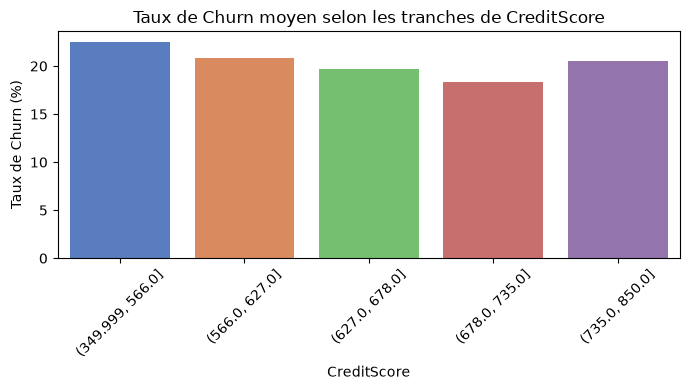




   ANALYSE DE LA VARIABLE : Age

--- Statistiques de Age selon le churn (Exited) ---


,mean,median
Exited,,
0,37.408389,36.0
1,44.837997,45.0


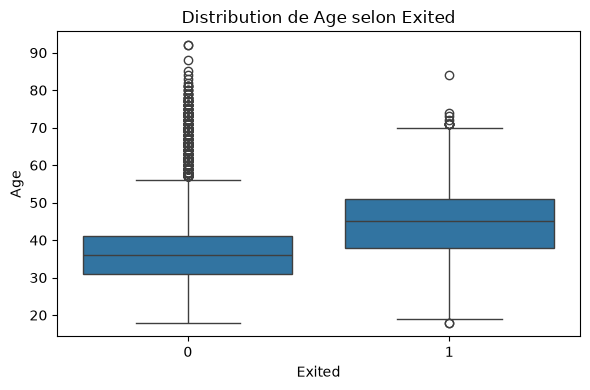


--- Taux de Churn selon les tranches de Age ---


,Taux de Churn (%)
Age,
"(17.999, 31.0]",7.630691
"(31.0, 35.0]",9.320606
"(35.0, 40.0]",14.960282
"(40.0, 46.0]",28.596698
"(46.0, 92.0]",45.941645


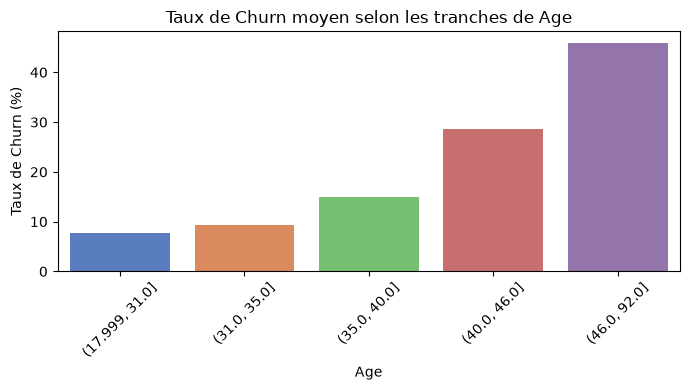




   ANALYSE DE LA VARIABLE : Tenure

--- Statistiques de Tenure selon le churn (Exited) ---


,mean,median
Exited,,
0,5.033279,5.0
1,4.932744,5.0


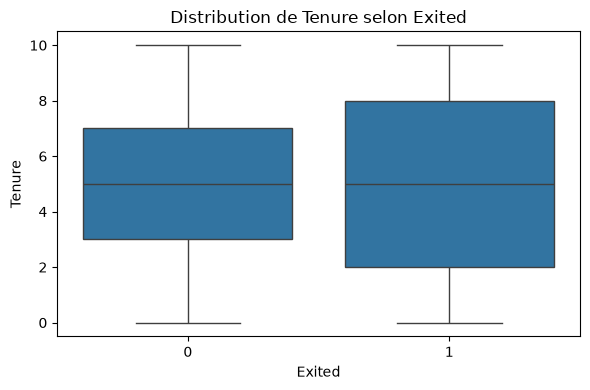


--- Taux de Churn selon les tranches de Tenure ---


,Taux de Churn (%)
Tenure,
0,23.002421
1,22.415459
2,19.179389
3,21.110010
4,20.525784
5,20.652174
6,20.268873
7,17.217899
8,19.219512


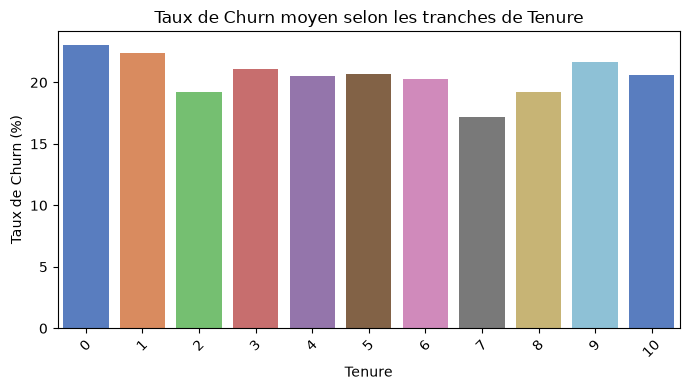




   ANALYSE DE LA VARIABLE : Balance

--- Statistiques de Balance selon le churn (Exited) ---


,mean,median
Exited,,
0,72745.296779,92072.68
1,91108.539337,109349.29


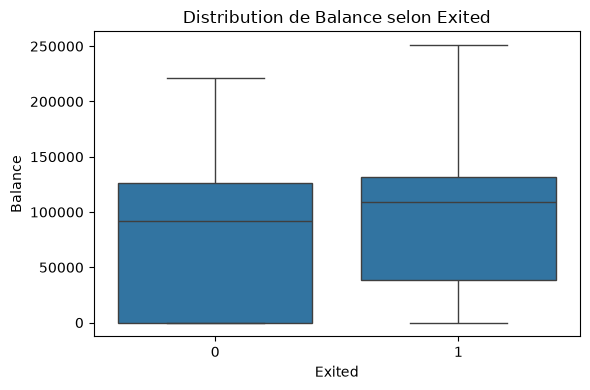


--- Taux de Churn selon les tranches de Balance ---


,Taux de Churn (%)
Balance,
"(-0.001, 73080.908]",14.75
"(73080.908, 110138.926]",22.30
"(110138.926, 133710.358]",26.95
"(133710.358, 250898.09]",23.10


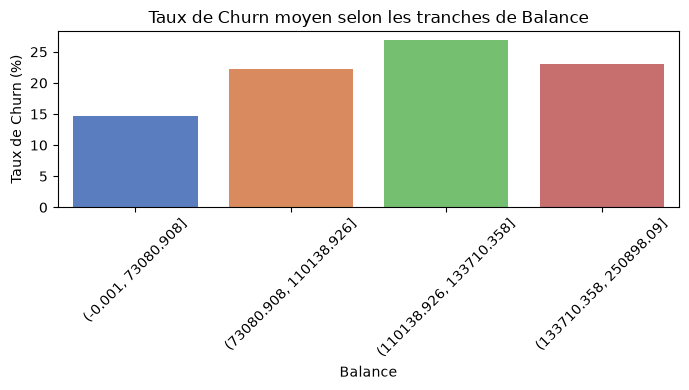




   ANALYSE DE LA VARIABLE : NumOfProducts

--- Statistiques de NumOfProducts selon le churn (Exited) ---


,mean,median
Exited,,
0,1.544267,2.0
1,1.475209,1.0


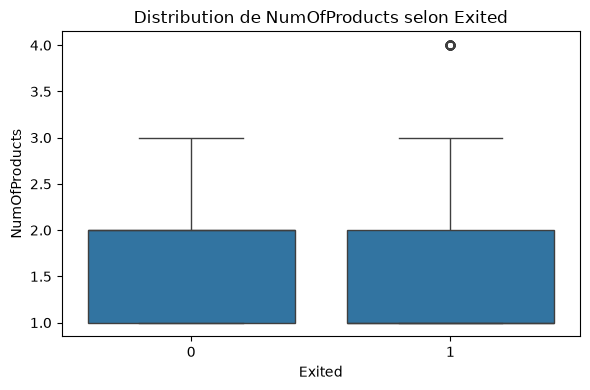


--- Taux de Churn selon les tranches de NumOfProducts ---


,Taux de Churn (%)
NumOfProducts,
1,27.714398
2,7.581699
3,82.706767
4,100.000000


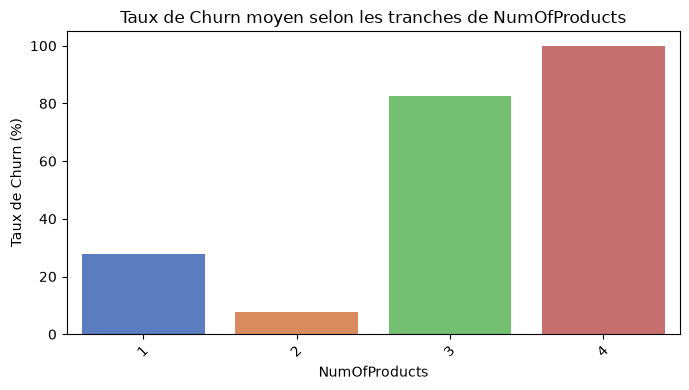




   ANALYSE DE LA VARIABLE : EstimatedSalary

--- Statistiques de EstimatedSalary selon le churn (Exited) ---


,mean,median
Exited,,
0,99738.391772,99645.04
1,101465.677531,102460.84


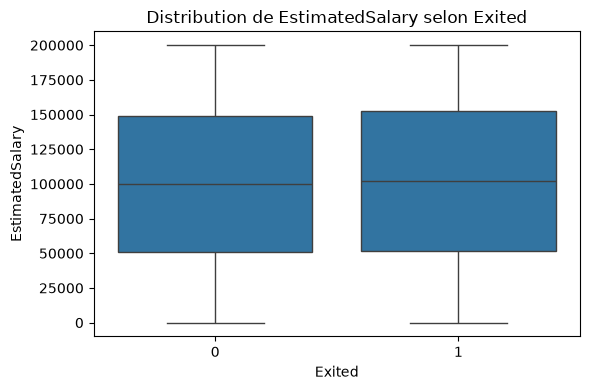


--- Taux de Churn selon les tranches de EstimatedSalary ---


,Taux de Churn (%)
EstimatedSalary,
"(11.579, 41050.736]",19.95
"(41050.736, 80238.34]",19.95
"(80238.34, 119710.038]",20.20
"(119710.038, 159836.726]",20.20
"(159836.726, 199992.48]",21.55


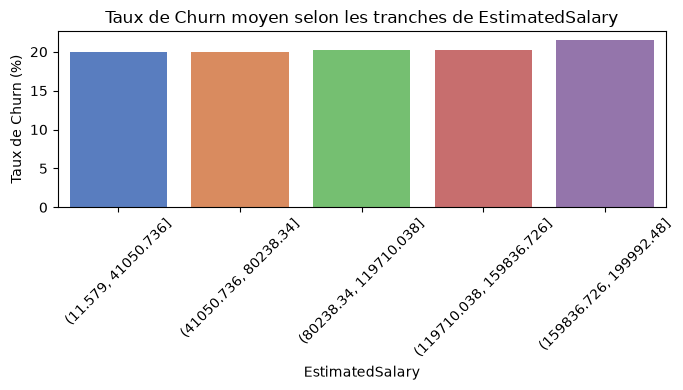

In [12]:
# --- BLOC 3a : VARIABLES NUMERIQUES vs CIBLE ---
for col in numerical_features:
    print(f"\n" + "="*40)
    print(f"   ANALYSE DE LA VARIABLE : {col}")
    print("="*40 + "\n")
    
    # 1. Comparaison de la moyenne et de la médiane
    print(f"--- Statistiques de {col} selon le churn (Exited) ---")
    display(df.groupby("Exited")[col].agg(["mean", "median"]))
    
    # 2. Boxplot pour voir la distribution
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Exited", y=col)
    plt.title(f"Distribution de {col} selon Exited")
    plt.tight_layout()
    plt.show()

    # 3. Taux de Churn par tranches (bins)
    print(f"\n--- Taux de Churn selon les tranches de {col} ---")
    if df[col].nunique() < 12:
        # Variables discrètes (ex: NumOfProducts, Tenure)
        grouped = df.groupby(col)['Exited'].mean() * 100
    else:
        # Variables continues : on divise en 5 groupes équilibrés (quantiles)
        # duplicates='drop' gère le cas de Balance où beaucoup de valeurs sont à 0
        bins = pd.qcut(df[col], q=5, duplicates='drop')
        grouped = df.groupby(bins, observed=True)['Exited'].mean() * 100
        
    display(grouped.to_frame(name="Taux de Churn (%)"))
    
    # Visualisation du Taux de Churn
    plt.figure(figsize=(7,4))
    x_labels = grouped.index.astype(str)
    sns.barplot(x=x_labels, y=grouped.values, hue=x_labels, palette="muted", legend=False)
    plt.ylabel("Taux de Churn (%)")
    plt.title(f"Taux de Churn moyen selon les tranches de {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\n")

---
### 📊 Interprétation — Bloc 3a : Variables Numériques vs Cible

**La découverte la plus importante : `NumOfProducts`**
Ce n'est ni monotone ni linéaire. Le churn descend d'abord (1 produit = 27.7% → 2 produits = 7.6%), puis **explose** (3 produits = 82.7%, 4 produits = 100%). C'est le cas d'école d'une relation non linéaire, invisible dans une matrice de corrélation classique ! C'est la variable la plus discriminante du dataset.

**Révision du classement avec les vrais chiffres :**
| Variable | Verdict | Preuve |
|---|---|---|
| `NumOfProducts` | 🔴 **Très forte** | Rupture spectaculaire de 7.6% à 100% selon la modalité. |
| `Age` | 🔴 **Forte** | Progression nette et régulière du churn : 7.6% chez les jeunes → 45.9% chez les plus âgés. |
| `Balance` | 🟡 **Signal réel, complexe** | Le taux progresse globalement, mais est fortement lié à `Geography` (voir vérification en fin de notebook). |
| `CreditScore` | ⚪ **Négligeable** | Taux quasi plat entre 18% et 22.5%, aucune tendance claire. |
| `Tenure` | ⚪ **Négligeable** | Taux flottant entre 17% et 23% sans tendance (médiane identique de 5 ans pour les 2 groupes). |
| `EstimatedSalary` | ⚪ **Négligeable** | Taux quasi identique partout (~20%). Confirme que sa distribution uniforme n'a aucun impact. |

--- Taux de Churn selon Geography ---


,Taux de Churn (%)
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


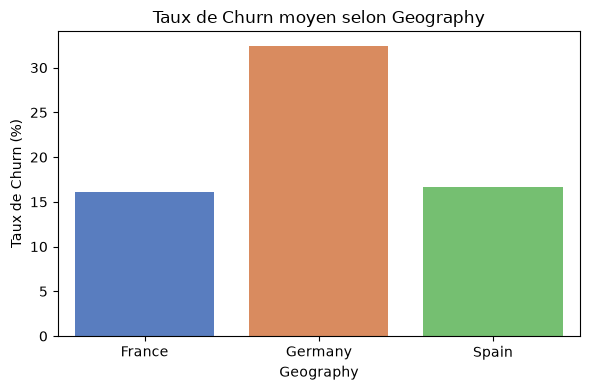

--- Taux de Churn selon HasCrCard ---


,Taux de Churn (%)
HasCrCard,
0,20.814941
1,20.184266


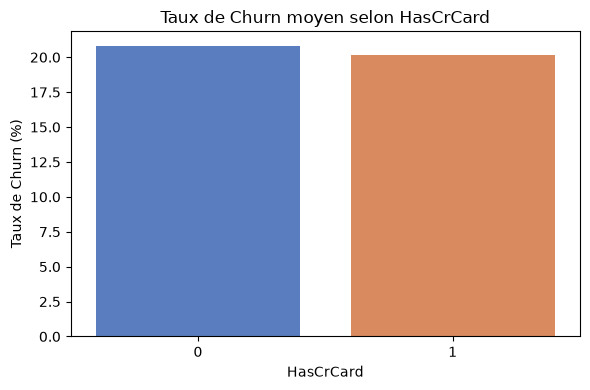

--- Taux de Churn selon IsActiveMember ---


,Taux de Churn (%)
IsActiveMember,
0,26.850897
1,14.269074


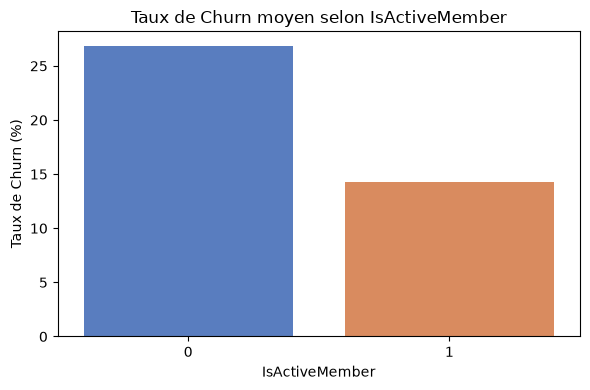

In [13]:
# --- BLOC 3b : VARIABLES CATEGORIELLES vs CIBLE ---
# Taux de churn moyen (%) pour chaque modalité de chaque variable catégorielle

features_to_plot = [col for col in categorical_features if col != 'Exited']

for col in features_to_plot:
    print(f"--- Taux de Churn selon {col} ---")
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    display(churn_rate.to_frame(name="Taux de Churn (%)"))
    plt.figure(figsize=(6, 4))
    sns.barplot(x=churn_rate.index, y=churn_rate.values,
                hue=churn_rate.index, palette="muted", legend=False)
    plt.ylabel("Taux de Churn (%)")
    plt.title(f"Taux de Churn moyen selon {col}")
    plt.tight_layout()
    plt.show()

---
###  Interprétation — Bloc 3b : Variables Catégorielles vs Cible

**Quelles variables catégorielles influencent le taux de churn ?**

| Variable | Modalité | Taux de churn | Signal |
|---|---|---|---|
| `Geography` | Allemagne | ~32% |  **Très fort** |
| `Geography` | France / Espagne | ~16% | — |
| `IsActiveMember` | Inactif (0) | ~27% |  **Fort** |
| `IsActiveMember` | Actif (1) | ~14% | — |
| `HasCrCard` | Oui / Non | ~20% / ~20% |  Aucun |

- **`Geography`** : Le marché **allemand perd 2× plus de clients** que la France et l'Espagne. C'est un signal géographique fort à exploiter dans le modèle.
- **`IsActiveMember`** : Un client inactif a **presque 2× plus de chances de partir**. L'engagement est un facteur de rétention clé.
- **`HasCrCard`** : Posséder une carte de crédit n'a **aucun impact** sur le churn. Cette variable sera probablement peu utile pour le modèle.

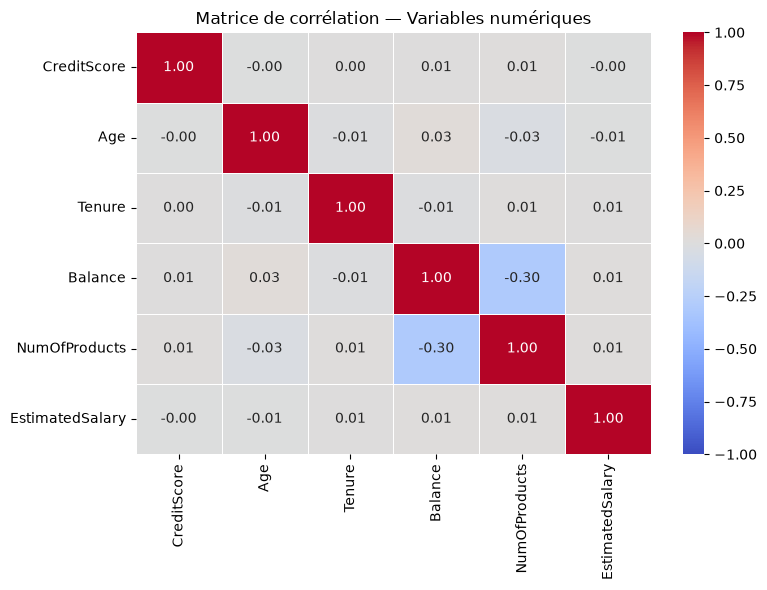

In [14]:
# --- BLOC 4 : MATRICE DE CORRÉLATION ---
# Permet de détecter si des variables numériques sont redondantes entre elles

plt.figure(figsize=(8, 6))
corr_matrix = df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matrice de corrélation — Variables numériques")
plt.tight_layout()
plt.show()

In [15]:
# === VERIFICATION CROISEE : Balance au sein de chaque pays ===
# Objectif : vérifier si Balance garde un signal propre, indépendant de Geography

print("TEST — Taux de churn de Balance à l'intérieur de chaque pays")
for geo in df['Geography'].unique():
    sub = df[df['Geography'] == geo].copy()
    try:
        sub['balance_bin'] = pd.qcut(sub['Balance'], q=4, duplicates='drop')
        print(f'\n--- {geo} (N={len(sub)}) ---')
        display(sub.groupby('balance_bin')['Exited'].mean().mul(100).to_frame('Taux de churn (%)'))
    except Exception:
        pass

TEST — Taux de churn de Balance à l'intérieur de chaque pays

--- France (N=5014) ---


,Taux de churn (%)
balance_bin,
"(-0.001, 62153.5]",14.758676
"(62153.5, 121444.878]",15.642458
"(121444.878, 238387.56]",19.457735



--- Spain (N=2477) ---


,Taux de churn (%)
balance_bin,
"(-0.001, 61710.44]",14.366425
"(61710.44, 121056.63]",18.739903
"(121056.63, 250898.09]",19.224556



--- Germany (N=2509) ---


,Taux de churn (%)
balance_bin,
"(27288.429, 102800.72]",22.292994
"(102800.72, 119703.1]",44.178628
"(119703.1, 137560.38]",37.958533
"(137560.38, 214346.96]",25.358852


---
### 📊 Synthèse Finale (Bloc 5) — Clôture Phase 2

#### Décision 1 : `Balance` — signal réel mais conditionné par `Geography`

Le taux de churn selon `Balance` varie de manière **différente selon le pays** :
- **France / Espagne** : Léger effet linéaire (de ~14% pour les petits soldes à ~19% pour les gros soldes).
- **Allemagne** : Effet **non-linéaire en cloche** — le churn culmine à **44%** pour les soldes intermédiaires (100k–120k), puis redescend à 25% pour les très hauts soldes.

→ `Balance` conserve un **effet propre** à l'intérieur de chaque pays. Elle est **conservée** dans le dataset.

#### Décision 2 : Variables faibles (`CreditScore`, `Tenure`, `EstimatedSalary`, `HasCrCard`)

Ces variables sont **négligeables en analyse bivariée** (effet seul vs cible plat à ~20%). Mais les modèles à base d'arbres (Random Forest, XGBoost) peuvent détecter des **effets d'interaction** que ce test ne voit pas.

**Stratégie à deux niveaux :**
- **Régression Logistique (baseline)** : Les exclure. Un modèle linéaire ne capte pas les interactions sans les construire explicitement.
- **Random Forest / XGBoost** : Les garder. Le modèle les éliminera via l'importance des features s'elles ne servent à rien.

---

#### Feuille de Route Phase 3 — Préparation des données

| Action | Variable | Méthode | Modèles concernés |
|---|---|---|---|
| Encodage catégoriel | `Geography` | One-Hot Encoding | Tous |
| Feature Engineering | `NumOfProducts` | Regrouper 3 et 4 en "3+" | Tous |
| Mise à l'échelle | `Age`, `Balance`, etc. | StandardScaler | Régression Logistique |
| Sélection de features | `CreditScore`, `Tenure`, etc. | Exclure pour LR, garder pour RF/XGB | Selon le modèle |
| Gestion du déséquilibre | `Exited` (80/20) | `class_weight='balanced'` ou SMOTE | Tous |